Our goal is to simplify the Lagrange equations of the first kind for our system, obtaining numerically solvable ODEs in the process.

In [46]:
#small angle approximation
approx = 0
#variables and functions
t, R, M, m, alpha, g, B1, B2, B3, A1, A2 = var('t R M m alpha g B1 B2 B3 A1 A2') 
#t is time, R is radius, M is mass, m is total magnetic moment, alpha is slope, g is gravitational acceleration, B are magnetic field comps, A are integration constants
x = function('x')(t)
y = function('y')(t)
phi = function('phi')(t)
psi = function('psi')(t)
theta = function('theta')(t)
#we need some symbolic derivatives
phidd, psidd, thetadd = var('phidd psidd thetadd')
#lagrange equations as labled in my sheet
A = diff(x,t) == R*(phi.diff()*sin(theta)*cos(psi)+alpha*phi.diff()*cos(theta)-theta.diff()*sin(psi)+alpha*psi.diff())
B = diff(y,t) == R*(phi.diff()*sin(theta)*sin(psi)+theta.diff()*cos(psi))
if approx:
    A = A.subs({sin(phi):phi, sin(psi):psi, sin(theta):theta, cos(phi):1, cos(psi):1, cos(theta):1})
    B = B.subs({sin(phi):phi, sin(psi):psi, sin(theta):theta, cos(phi):1, cos(psi):1, cos(theta):1})
    A = A.full_simplify()
    B = B.full_simplify()
dA = diff(x,t,2) == diff(A.rhs(),t,1) #differentiate only once as A already contains the first derivative of x
dB = diff(y,t,2) == diff(B.rhs(),t,1)

C = 0 == (5*R^2*M*(phi.diff(2)+psi.diff(2)*cos(theta)-psi.diff()*theta.diff()*sin(theta)) -m*(B1*cos(phi)*sin(theta)+B2*sin(phi)*sin(theta))+M*R*x.diff(2)*(sin(theta)*cos(psi)+alpha*cos(theta))  
- (M*R*x.diff()+A1)*(psi.diff()*sin(theta)*sin(psi)+alpha*theta.diff()*sin(theta)-theta.diff()*cos(theta)*cos(psi)) + (R*m*(1-alpha^2)*y.diff()-R*M*g*alpha*t+A2)*(theta.diff()*cos(theta)*sin(psi)+psi.diff()*sin(theta)*cos(psi))
    -R*M*(g*alpha-y.diff(2)*(1+alpha^2)) * sin(theta)*sin(psi))
C = C.subs({ x.diff(): A.rhs(), y.diff():B.rhs(), x.diff(2):dA.rhs(), y.diff(2):dB.rhs()})
D = 0 == (5*R^2*M*theta.diff(2) + m * (-B1*sin(phi)*cos(theta)+B2*cos(phi)*cos(theta)+B3*sin(theta)) - ( M * R * x.diff() + A1 ) * ( phi.diff() * cos(theta) * cos(psi) - alpha * phi.diff()*sin(theta) + psi.diff() * cos(psi))
    - M*R*x.diff(2)*sin(psi) - (-R*M*(1+alpha^2)*y.diff()+R*M*g*alpha*t+A2)*sin(psi)*(phi.diff()*cos(theta)*sin(psi)-1)-R*M*(g*alpha - y.diff(2)*(1+alpha^2))*cos(psi) )
D = D.subs({ x.diff(): A.rhs(), y.diff():B.rhs(), x.diff(2):dA.rhs(), y.diff(2):dB.rhs()})
E = 0 == (5*R^2*M*(psi.diff(2)+phi.diff(2)*cos(theta)-theta.diff()*phi.diff()*sin(theta)) - (M*R*x.diff() + A1) * (phi.diff() * sin(theta)*sin(psi)+theta.diff()*cos(psi))
         - alpha*M*R*x.diff(2)+(-R*M*(1+alpha^2)*y.diff()+R*M*g*alpha*t+A2) * (theta.diff()*sin(psi)-phi.diff()*sin(theta)*cos(psi)) )
E = E.subs({ x.diff(): A.rhs(), y.diff():B.rhs(), x.diff(2):dA.rhs(), y.diff(2):dB.rhs() })
if approx:
    C = C.subs({sin(phi):phi, sin(psi):psi, sin(theta):theta, cos(phi):1, cos(psi):1, cos(theta):1})
    D = D.subs({sin(phi):phi, sin(psi):psi, sin(theta):theta, cos(phi):1, cos(psi):1, cos(theta):1})
    E = E.subs({sin(phi):phi, sin(psi):psi, sin(theta):theta, cos(phi):1, cos(psi):1, cos(theta):1})
C = C.full_simplify()
D = D.full_simplify()
E = E.full_simplify()
show(A)
show(dA)
show(B)
show(dB)
show(C)
show(D)
show(E)

diff(x(t), t) == (alpha*cos(theta(t))*diff(phi(t), t) + cos(psi(t))*sin(theta(t))*diff(phi(t), t) + alpha*diff(psi(t), t) - sin(psi(t))*diff(theta(t), t))*R

diff(x(t), t, t) == -(sin(psi(t))*sin(theta(t))*diff(phi(t), t)*diff(psi(t), t) - cos(psi(t))*cos(theta(t))*diff(phi(t), t)*diff(theta(t), t) + alpha*sin(theta(t))*diff(phi(t), t)*diff(theta(t), t) - alpha*cos(theta(t))*diff(phi(t), t, t) - cos(psi(t))*sin(theta(t))*diff(phi(t), t, t) + cos(psi(t))*diff(psi(t), t)*diff(theta(t), t) - alpha*diff(psi(t), t, t) + sin(psi(t))*diff(theta(t), t, t))*R

diff(y(t), t) == (sin(psi(t))*sin(theta(t))*diff(phi(t), t) + cos(psi(t))*diff(theta(t), t))*R

diff(y(t), t, t) == (cos(psi(t))*sin(theta(t))*diff(phi(t), t)*diff(psi(t), t) + cos(theta(t))*sin(psi(t))*diff(phi(t), t)*diff(theta(t), t) + sin(psi(t))*sin(theta(t))*diff(phi(t), t, t) - sin(psi(t))*diff(psi(t), t)*diff(theta(t), t) + cos(psi(t))*diff(theta(t), t, t))*R

0 == -(M*R^2*alpha^2*cos(psi(t))^2*diff(phi(t), t, t) - (M*R^2*alpha^2 - M*R^2 - (R^2*alpha^2 - R^2)*m)*cos(psi(t))*sin(psi(t))*diff(phi(t), t)*diff(psi(t), t) - M*R^2*diff(phi(t), t, t))*sin(theta(t))^2 + (M*R^2*alpha^2 + 5*M*R^2)*cos(theta(t))*diff(psi(t), t, t) + (M*R^2*alpha*sin(psi(t))*sin(theta(t)) - (M*R^2 + (R^2*alpha^2 - R^2)*m)*cos(psi(t))*cos(theta(t))*sin(psi(t)))*diff(theta(t), t)^2 - (M*R^2*alpha*sin(psi(t))*diff(psi(t), t)^2 - M*R^2*alpha*cos(psi(t))*diff(psi(t), t, t) + M*R*alpha*g*sin(psi(t)) + B1*m*cos(phi(t)) + B2*m*sin(phi(t)) + 2*(M*R^2*alpha*sin(psi(t))*diff(phi(t), t)*diff(psi(t), t) - M*R^2*alpha*cos(psi(t))*diff(phi(t), t, t))*cos(theta(t)) + ((M*R*alpha*g*t - A2)*cos(psi(t)) + A1*sin(psi(t)))*diff(psi(t), t))*sin(theta(t)) + (M*R^2*alpha^2 + 5*M*R^2)*diff(phi(t), t, t) - (4*M*R^2*alpha*cos(psi(t))*sin(theta(t))^2*diff(phi(t), t) - 2*M*R^2*alpha*cos(psi(t))*diff(phi(t), t) - (A1*cos(psi(t)) - (M*R*alpha*g*t - A2)*sin(psi(t)))*cos(theta(t)) + (A1*alpha + ((M*R^2*alpha^2 - M*R^2 - (R^2*alpha^2 - R^2)*m)*cos(psi(t))^2*diff(phi(t), t) + (M*R^2*alpha^2 - M*R^2 + (R^2*alpha^2 - R^2)*m)*diff(phi(t), t))*cos(theta(t)) + (2*M*R^2*alpha^2 + 5*M*R^2 - (M*R^2*alpha^2 - M*R^2 - (R^2*alpha^2 - R^2)*m)*cos(psi(t))^2)*diff(psi(t), t))*sin(theta(t)))*diff(theta(t), t) + (M*R^2*alpha^2*cos(psi(t))*sin(psi(t))*sin(theta(t)) - M*R^2*alpha*cos(theta(t))*sin(psi(t)))*diff(theta(t), t, t)

0 == -2*M*R^2*alpha*cos(psi(t))*cos(theta(t))^2*diff(phi(t), t)^2 - M*R^2*alpha*cos(psi(t))*diff(psi(t), t)^2 - M*R^2*alpha*sin(psi(t))*diff(psi(t), t, t) - A1*cos(psi(t))*diff(psi(t), t) + (M*R^2*alpha*diff(phi(t), t)^2 - M*R*alpha*g)*cos(psi(t)) - (2*M*R^2*alpha*cos(psi(t))*diff(phi(t), t)*diff(psi(t), t) + M*R^2*alpha*sin(psi(t))*diff(phi(t), t, t) + (M*R*alpha*g*t + A2)*sin(psi(t))^2*diff(phi(t), t) - B2*m*cos(phi(t)) + B1*m*sin(phi(t)) + A1*cos(psi(t))*diff(phi(t), t))*cos(theta(t)) + (M*R*alpha*g*t + A2)*sin(psi(t)) + (M*R^2*alpha^2*cos(psi(t))*sin(psi(t))*diff(phi(t), t, t) - (M*R^2*alpha^2 + M*R^2)*sin(psi(t))^2*diff(phi(t), t) + A1*alpha*diff(phi(t), t) + B3*m + (M*R^2*sin(psi(t))^2*diff(phi(t), t)^2 + (M*R^2*alpha^2 + M*R^2)*sin(psi(t))^3*diff(phi(t), t)^2 + (M*R^2*alpha^2 - M*R^2)*diff(phi(t), t)^2)*cos(theta(t)) + (2*M*R^2*alpha^2*diff(phi(t), t) - (M*R^2*alpha^2 - M*R^2)*sin(psi(t))^2*diff(phi(t), t))*diff(psi(t), t))*sin(theta(t)) - ((M*R^2*alpha^2 - M*R^2)*cos(psi(t))*sin(psi(t))*diff(psi(t), t) + (M*R^2*alpha^2 + M*R^2)*cos(psi(t))*sin(psi(t)) - ((M*R^2*alpha^2 + M*R^2)*cos(psi(t))*sin(psi(t))^2*diff(phi(t), t) + (M*R^2*alpha^2 + M*R^2)*cos(psi(t))*sin(psi(t))*diff(phi(t), t))*cos(theta(t)))*diff(theta(t), t) - (M*R^2*alpha^2*sin(psi(t))^2 - M*R^2*alpha^2 - 6*M*R^2)*diff(theta(t), t, t)

0 == M*R^2*alpha^2*cos(psi(t))*sin(psi(t))*sin(theta(t))^2*diff(phi(t), t)^2 - M*R^2*alpha^2*cos(psi(t))*sin(psi(t))*diff(theta(t), t)^2 + M*R^2*alpha*sin(psi(t))*diff(theta(t), t, t) - (M*R^2*alpha^2 - 5*M*R^2)*cos(theta(t))*diff(phi(t), t, t) - (M*R^2*alpha*cos(theta(t))*sin(psi(t))*diff(phi(t), t)^2 + A1*sin(psi(t))*diff(phi(t), t) + (M*R^2*alpha*diff(phi(t), t, t) + (M*R*alpha*g*t + A2)*diff(phi(t), t))*cos(psi(t)))*sin(theta(t)) - (M*R^2*alpha^2 - 5*M*R^2)*diff(psi(t), t, t) - (2*M*R^2*alpha*cos(psi(t))*cos(theta(t))*diff(phi(t), t) + A1*cos(psi(t)) - (M*R*alpha*g*t + A2)*sin(psi(t)) - (2*M*R^2*alpha^2*cos(psi(t))^2*diff(phi(t), t) - 5*M*R^2*diff(phi(t), t))*sin(theta(t)))*diff(theta(t), t)

Now we try a numerical approach. First, we need explicit forms for the three remaining coupled ODEs C-E to use the built-in ODE solver.

In [47]:
C = C.subs({ phi.diff(2):phidd, psi.diff(2):psidd, theta.diff(2):thetadd })
D = D.subs({ phi.diff(2):phidd, psi.diff(2):psidd, theta.diff(2):thetadd })
E = E.subs({ phi.diff(2):phidd, psi.diff(2):psidd, theta.diff(2):thetadd })
sol = solve([C, D, E], [phidd, psidd, thetadd], solution_dict=True)
phi_explicit   = sol[0][phidd]
psi_explicit   = sol[0][psidd]
theta_explicit = sol[0][thetadd]

The ODE solver needs symbolic expressions, so we replace everything accordingly.

In [48]:
X, Vx, Y, Vy, Phi, Vphi, Psi, Vpsi, Theta, Vtheta = var('X Vx Y Vy Phi Vphi Psi Vpsi Theta Vtheta')
state_vector = {x: X, y: Y, phi: Phi, phi.diff(): Vphi, psi: Psi, psi.diff(): Vpsi, theta: Theta, theta.diff(): Vtheta}
state_order = [X, Y, Phi, Vphi, Psi, Vpsi, Theta, Vtheta]
acc_vector = {phi.diff(2):phi_explicit, psi.diff(2):psi_explicit, theta.diff(2):theta_explicit}
phi_dd = phi_explicit.subs(state_vector)
psi_dd = psi_explicit.subs(state_vector)
theta_dd = theta_explicit.subs(state_vector)
x_d = A.rhs().subs(state_vector)
y_d = B.rhs().subs(state_vector)
x_dd = dA.rhs().subs(acc_vector).subs(state_vector) 
y_dd = dB.rhs().subs(acc_vector).subs(state_vector)

Now, we have a system of 10 coupled ODEs which we want to solve numerically.

In [60]:
f = [x_d, y_d, Vphi, phi_dd, Vpsi, psi_dd, Vtheta, theta_dd]
try_analytic = 0
if try_analytic:
    g = [x_d, x_dd, y_d, y_dd, Vphi, phi_dd, Vpsi, psi_dd, Vtheta, theta_dd]
    t = var('t')
    x = function('x')(t)
    v_x = function('v_x')(t)
    y = function('y')(t)
    v_y = function('v_y')(t)
    phi = function('phi')(t)
    v_phi = function('v_phi')(t)
    psi = function('psi')(t)
    v_psi = function('v_psi')(t)
    theta = function('theta')(t)
    v_theta = function('v_theta')(t)
    states = [x, v_x, y, v_y, phi, v_phi, psi, v_psi, theta, v_theta]
    eqs = [ diff(states[i], t) == g[i]  for i in range(len(states)) ]
    sol = desolve_system(eqs, states, ivar=t)
    from sage.misc.latex import latex
    from IPython.display import display, Math
    if sol is not None:
        for eq in sol:
            display(Math(latex(eq)))
    print("done")
#parameters
from scipy.constants import mu_0
B_residual = 12 * 10^3 * 10^(-4) #Residual Flux Density in Tesla (conversion Gauss * 10^-4 = Tesla)
dipole = (4 / 3) * pi * (0.1)^3 * B_residual / mu_0 #is that correct? The value is several orders of magnitude higher than a typical MRI magnet; for now, I go with an empirical value
parameters = {
    R: .5, M: 0.5, m: 5.0, alpha: -0.2, g: 9.81,
    B1: 0, B2:0, B3: 0.0, A1: 1.0, A2: 0.0
}
#inital values; note that the initial angles are technically also parameters as they determine the direction of m at t=0
X0 = 0.0
Y0 = 0.0
Phi0, Vphi0 = 0.0, 0.0
Psi0, Vpsi0 = 0.0, 0.0
Theta0, Vtheta0 = 0.01, 0.0 #Theta0 =/= ist nicht erlaubt, theta parametrisiert SO(3) ausgehend von der offenen Menge (0, pi/2) -> 0 ist einer der Pol-Singularitäten der Euler-Karte
initials = [X0, Y0, Phi0, Vphi0, Psi0, Vpsi0, Theta0, Vtheta0]
#solving
f_num = [expr.subs(parameters) for expr in f]
t0 = 0.0
t1 = .1 #for small angles: if m and B are turned on, this has to be very small, around 100ms; without m and B, 1s is possible; keep dt somewhat proportional for meaningful results
dt = .001
time = srange(t0, t1+dt, dt)
solode = desolve_odeint(f_num, initials, time, state_order)
print("done")

done


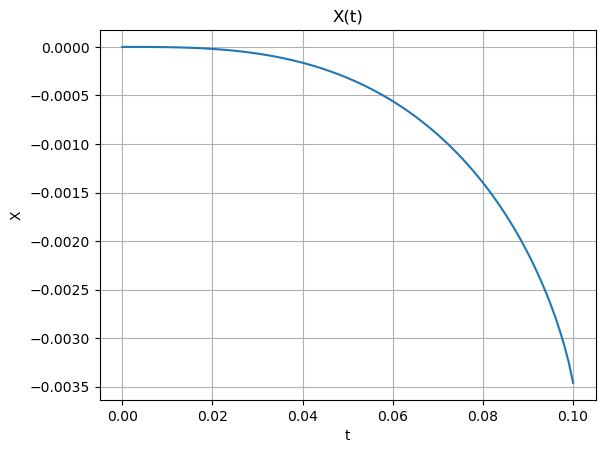

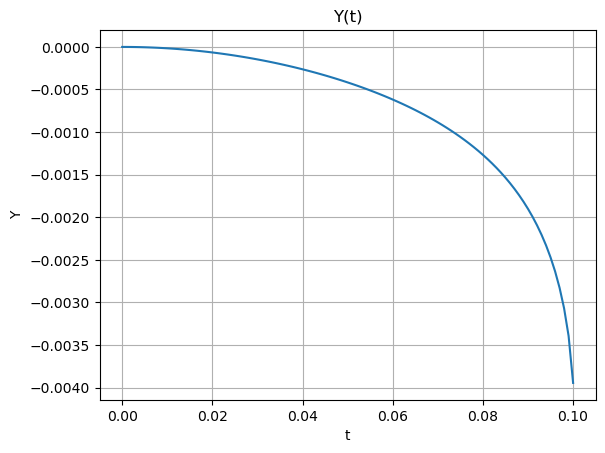

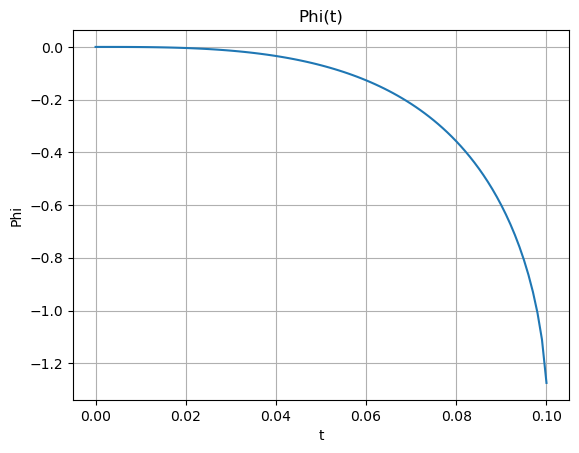

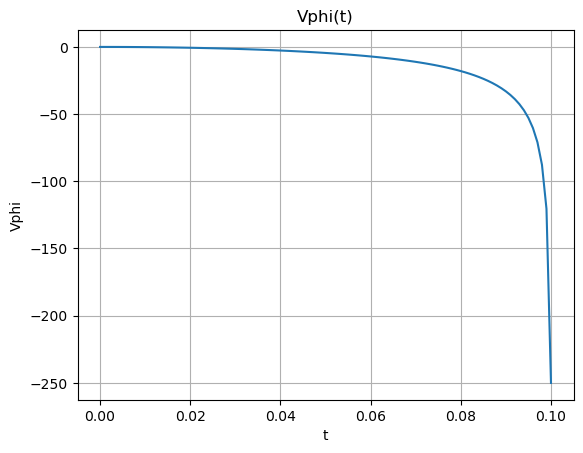

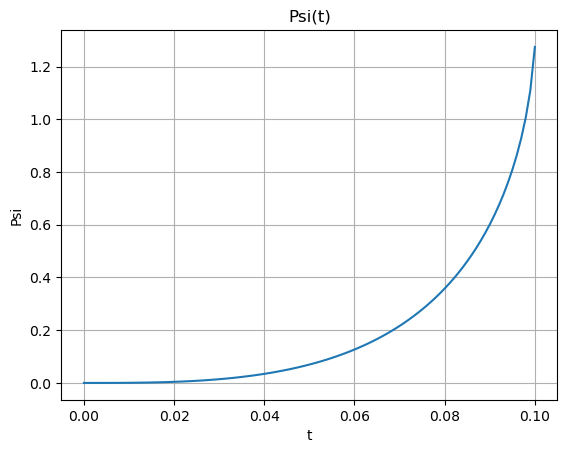

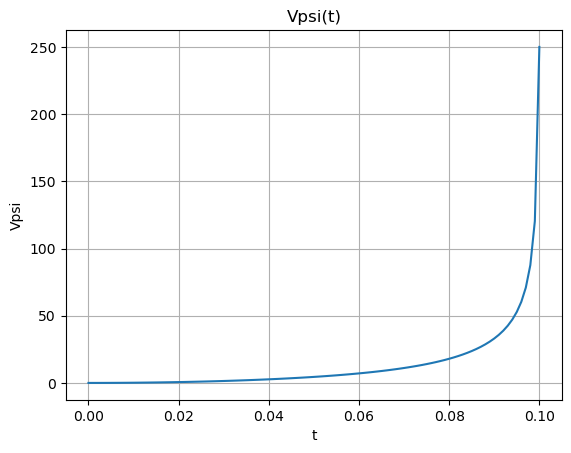

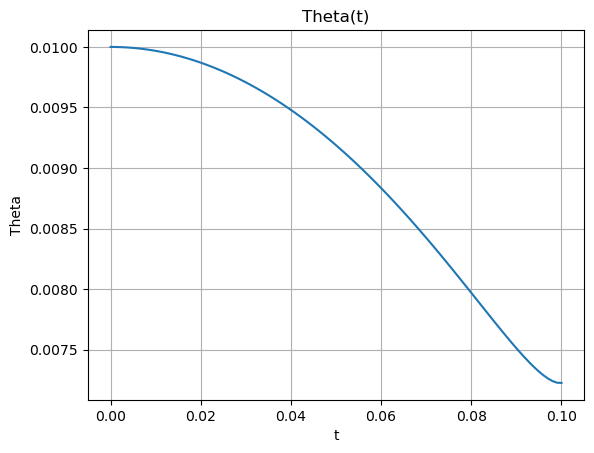

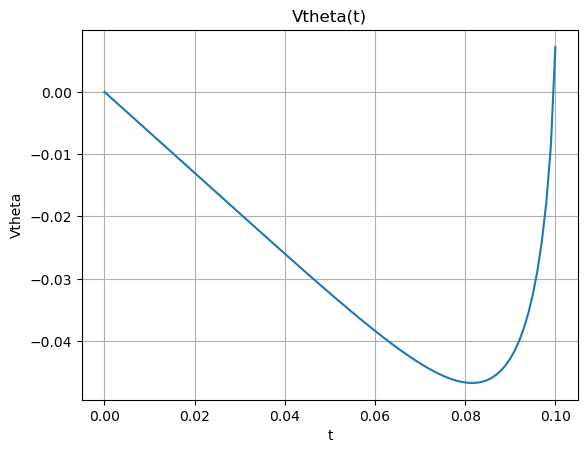

In [61]:
import matplotlib.pyplot as plt
names = ["X","Y","Phi","Vphi","Psi","Vpsi","Theta","Vtheta"]
for i,name in enumerate(names):
    plt.figure()
    plt.plot(time, solode[:,i])
    plt.xlabel("t"); plt.ylabel(name)
    plt.title(name+"(t)")
    plt.grid(True)
    plt.show()

The following animation code is from ChatGPT and therefore very rough, I just wanted to get an idea of the behaviour. As soon as I can type with both hands again, I will code a much nicer animation :)

Animation with 334 frames
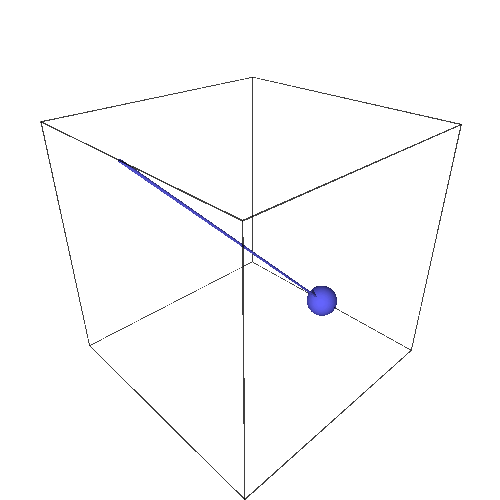

Saved animation as trajectory_orientation.gif
Animation created with 334 frames (step = 3).


In [11]:
# --------------------------
# 3D animation for your solode
# --------------------------
# state indices (as you defined):
# 0: X, 1: Vx, 2: Y, 3: Vy, 4: Phi, 5: Vphi, 6: Psi, 7: Vpsi, 8: Theta, 9: Vtheta

# ensure solode/time are plain lists
time = list(time)
solode = [ list(row) for row in solode ]

n_total = len(solode)
if n_total == 0:
    raise ValueError("solode is empty")

# parameters
R_val = float(parameters.get(R, 1.0))   # fallback to 1.0 if not present
# orientation indicator length: scale with R so it's visible but not huge
orient_length = 0.5 * R_val

# control number of frames (subsample if many steps)
max_frames = 300
step = max(1, n_total // max_frames)

frames = []
# create a lightweight style for trail (fainter)
for k in range(0, n_total, step):
    row = solode[k]
    tnow = float(time[k])

    Xv = float(row[0])
    Yv = float(row[2])

    # angles used to compute unit orientation vector
    Theta_v = float(row[8])
    Psi_v   = float(row[6])

    # orientation vector: visual choice
    ux = float(sin(Theta_v)*cos(Psi_v))
    uy = float(sin(Theta_v)*sin(Psi_v))
    uz = float(cos(Theta_v))

    # orientation line endpoints
    p0 = (Xv, Yv, 0.0)
    p1 = (Xv + orient_length*ux, Yv + orient_length*uy, orient_length*uz)

    # center point and orientation line
    center = point3d(p0, size=30)                         # a visible dot
    orient_line = line3d([p0, p1], thickness=2)

    # trajectory trace up to now (subsample trace points to speed up drawing)
    # keep at most 500 trace points
    max_trace_pts = 500
    trace_step = max(1, (k+1) // max_trace_pts)
    trace_pts = [ (float(solode[j][0]), float(solode[j][2]), 0.0) for j in range(0, k+1, trace_step) ]
    trace = line3d(trace_pts, thickness=1) if len(trace_pts) > 1 else point3d(trace_pts[0])

    # optional: draw velocity arrow (projected into XY plane) -- uncomment if useful
    # Vx = float(row[1]); Vy = float(row[3])
    # vel_scale = 0.2 * R_val
    # vel_arrow = arrow3d((Xv, Yv, 0), (Xv + vel_scale*Vx, Yv + vel_scale*Vy, 0))

    frame = center + orient_line + trace
    frames.append(frame)

# Build and show the animation
anim3d = animate(frames)
anim3d.show()   # display in the notebook (frontend permitting)

# Try saving as GIF (requires ImageMagick / imagemagick convert available)
try:
    anim3d.save('trajectory_orientation.gif')
    print("Saved animation as trajectory_orientation.gif")
except Exception as e:
    print("Could not save GIF (ImageMagick may be missing or saving not supported). Exception:", e)

print("Animation created with {} frames (step = {}).".format(len(frames), step))
